# Video Game Sales End-to-End Pipeline

This notebook combines exploratory analysis, preprocessing, model training, and explainability in one continuous workflow.

Use this as the primary project notebook for both experimentation and reporting.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)  # Removed the extra single quote after format

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


### 1.1 Data Loading and Initial Inspection



In [3]:
# Load data
df = pd.read_excel('VideoGames_Sales.xlsx')

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Date Range: {df['release_date'].min()} to {df['release_date'].max()}")



Dataset Shape: 64,016 rows × 12 columns
Memory Usage: 21.81 MB
Date Range: 1971-12-03 00:00:00 to 2024-12-31 00:00:00


In [4]:
# Display first rows
df.head(10)



,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10,15.09,6.18,0.41,6.05,2.44,2015-11-06
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.70,14.82,9.07,0.13,4.29,1.33,2011-11-08
6,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.80,14.74,9.76,0.11,3.73,1.14,2010-11-09
7,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.80,13.94,5.26,0.21,6.21,2.26,2018-10-26
8,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.40,13.86,8.27,0.07,4.32,1.20,2012-11-13
9,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.00,13.80,4.99,0.65,5.88,2.28,2012-11-13


In [5]:
# Data types and basic info
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             64016 non-null  object        
 1   console           64016 non-null  object        
 2   genre             64016 non-null  object        
 3   publisher         64016 non-null  object        
 4   developer         63999 non-null  object        
 5   critic_score      6678 non-null   float64       
 6   total_sales(mil)  18922 non-null  float64       
 7   na_sales(mil)     12637 non-null  float64       
 8   jp_sales(mil)     6726 non-null   float64       
 9   pal_sales(mil)    12824 non-null  float64       
 10  other_sales(mil)  15128 non-null  float64       
 11  release_date      56965 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), object(5)
memory usage: 5.9+ MB


In [6]:
# Statistical summary
df.describe(include='all').T



,count,unique,top,freq,mean,min,25%,50%,75%,max,std
title,64016,39798,Plants vs. Zombies,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
console,64016,81,PC,12617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,64016,20,Misc,9304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,64016,3383,Unknown,8842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,63999,8862,Unknown,4435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
critic_score,6678.00,NaN,NaN,NaN,7.22,1.00,6.40,7.50,8.30,10.00,1.46
total_sales(mil),18922.00,NaN,NaN,NaN,0.35,0.00,0.03,0.12,0.34,20.32,0.81
na_sales(mil),12637.00,NaN,NaN,NaN,0.26,0.00,0.05,0.12,0.28,9.76,0.49
jp_sales(mil),6726.00,NaN,NaN,NaN,0.10,0.00,0.02,0.04,0.12,2.13,0.17
pal_sales(mil),12824.00,NaN,NaN,NaN,0.15,0.00,0.01,0.04,0.14,9.85,0.39


### 1.2 Missing Data Analysis



In [7]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Percentage', ascending=False)

print("Missing Data Summary:")
print("=" * 50)
print(missing_data)



Missing Data Summary:
                  Missing_Count  Missing_Percentage
critic_score              57338               89.57
jp_sales(mil)             57290               89.49
na_sales(mil)             51379               80.26
pal_sales(mil)            51192               79.97
other_sales(mil)          48888               76.37
total_sales(mil)          45094               70.44
release_date               7051               11.01
developer                    17                0.03
title                         0                0.00
console                       0                0.00
genre                         0                0.00
publisher                     0                0.00


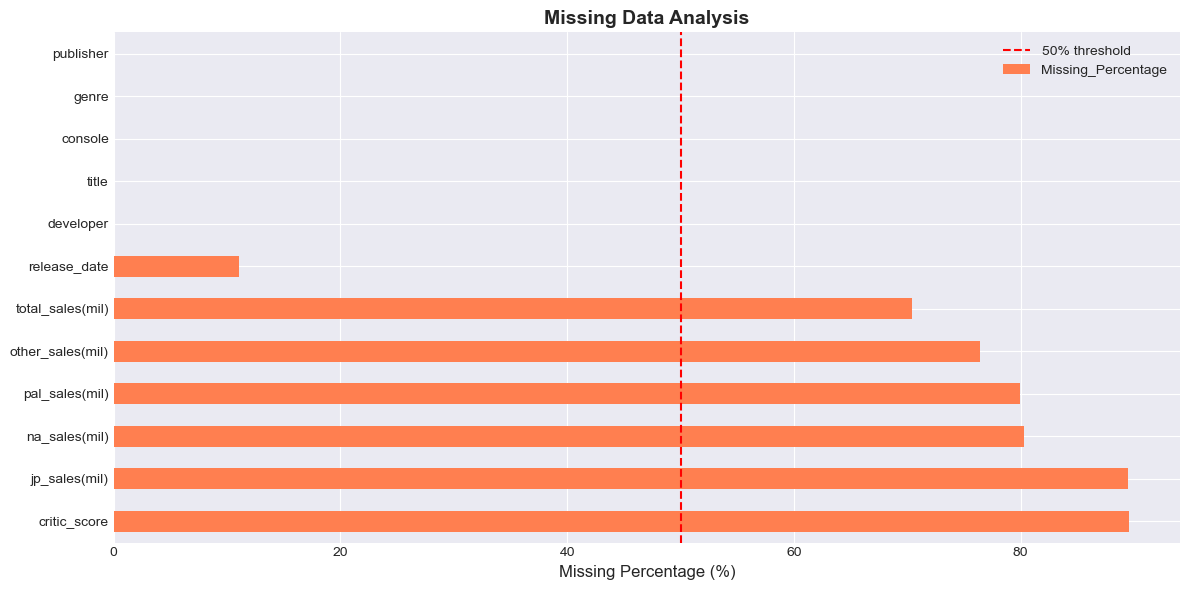


⚠️ CRITICAL: 6 columns have >50% missing data


In [8]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(12, 6))
missing_data['Missing_Percentage'].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Percentage (%)', fontsize=12)
ax.set_title('Missing Data Analysis', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n⚠️ CRITICAL: {missing_data[missing_data['Missing_Percentage'] > 50].shape[0]} columns have >50% missing data")



### 1.3 Sales Distribution Analysis



In [9]:
# Analyze sales data availability
sales_cols = ['total_sales(mil)', 'na_sales(mil)', 'jp_sales(mil)', 'pal_sales(mil)', 'other_sales(mil)']

df_sales = df.dropna(subset=['total_sales(mil)'])
print(f"Records with Total Sales Data: {len(df_sales):,} ({len(df_sales)/len(df)*100:.1f}% of dataset)")

print("\nSales Statistics (in millions):")
print("=" * 50)
print(df_sales[sales_cols].describe())



Records with Total Sales Data: 18,922 (29.6% of dataset)

Sales Statistics (in millions):
       total_sales(mil)  na_sales(mil)  jp_sales(mil)  pal_sales(mil)  \
count          18922.00       12637.00        6726.00        12824.00   
mean               0.35           0.26           0.10            0.15   
std                0.81           0.49           0.17            0.39   
min                0.00           0.00           0.00            0.00   
25%                0.03           0.05           0.02            0.01   
50%                0.12           0.12           0.04            0.04   
75%                0.34           0.28           0.12            0.14   
max               20.32           9.76           2.13            9.85   

       other_sales(mil)  
count          15128.00  
mean               0.04  
std                0.13  
min                0.00  
25%                0.00  
50%                0.01  
75%                0.03  
max                3.12  


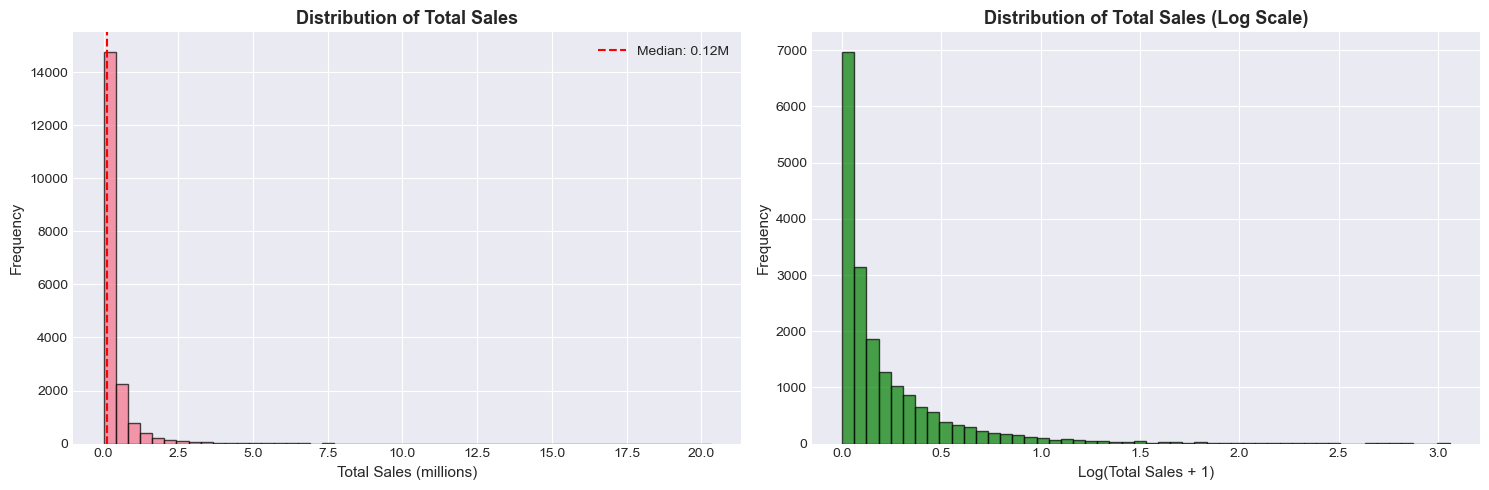


📊 Sales are highly right-skewed. Median: 0.12M, Mean: 0.35M


In [10]:
# Distribution of total sales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_sales['total_sales(mil)'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Sales (millions)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Total Sales', fontsize=13, fontweight='bold')
axes[0].axvline(df_sales['total_sales(mil)'].median(), color='red', linestyle='--', 
                label=f"Median: {df_sales['total_sales(mil)'].median():.2f}M")
axes[0].legend()

# Log scale
axes[1].hist(np.log1p(df_sales['total_sales(mil)']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log(Total Sales + 1)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Total Sales (Log Scale)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Sales are highly right-skewed. Median: {df_sales['total_sales(mil)'].median():.2f}M, Mean: {df_sales['total_sales(mil)'].mean():.2f}M")



Top 20 Best-Selling Games:
                         title console  total_sales(mil) release_date
            Grand Theft Auto V     PS3             20.32   2013-09-17
            Grand Theft Auto V     PS4             19.39   2014-11-18
   Grand Theft Auto: Vice City     PS2             16.15   2002-10-28
            Grand Theft Auto V    X360             15.86   2013-09-17
     Call of Duty: Black Ops 3     PS4             15.09   2015-11-06
Call of Duty: Modern Warfare 3    X360             14.82   2011-11-08
       Call of Duty: Black Ops    X360             14.74   2010-11-09
         Red Dead Redemption 2     PS4             13.94   2018-10-26
    Call of Duty: Black Ops II    X360             13.86   2012-11-13
    Call of Duty: Black Ops II     PS3             13.80   2012-11-13
Call of Duty: Modern Warfare 2    X360             13.53   2009-11-10
            Call of Duty: WWII     PS4             13.40   2017-11-03
Call of Duty: Modern Warfare 3     PS3             13.35   2011

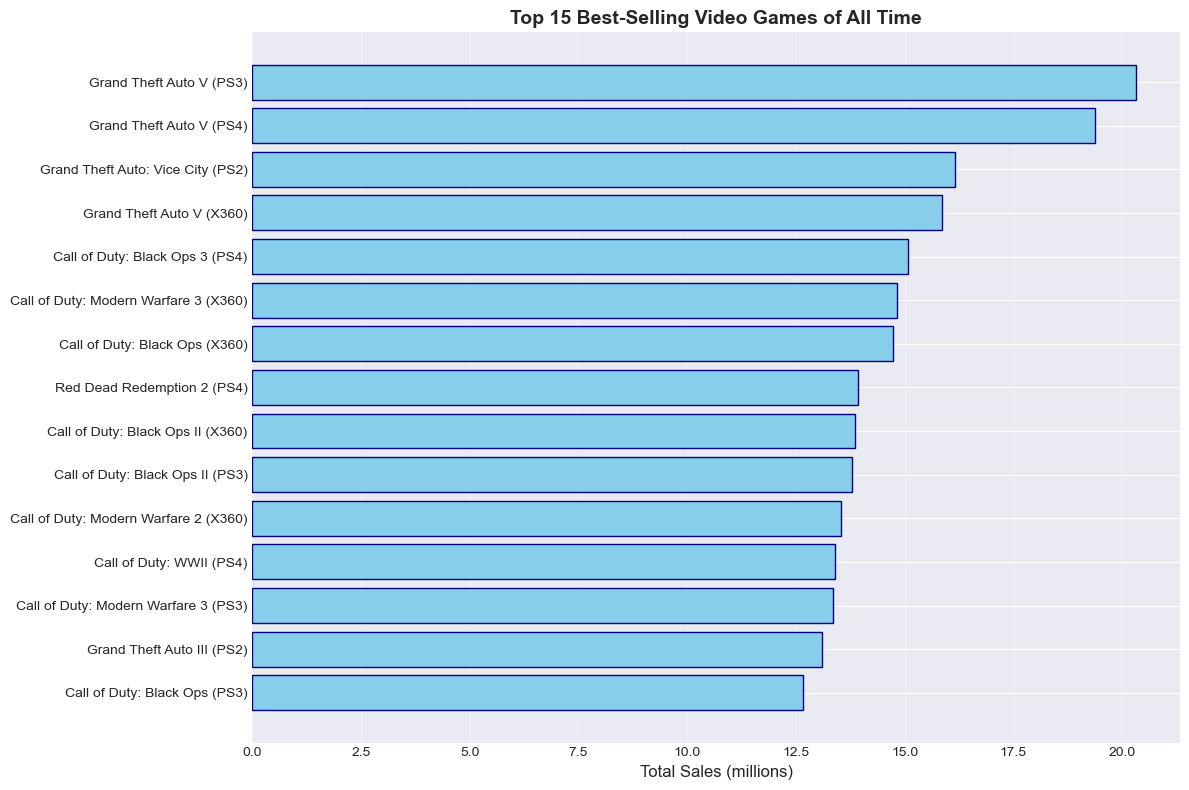

In [11]:
# Top 20 best-selling games
top_games = df_sales.nlargest(20, 'total_sales(mil)')[['title', 'console', 'total_sales(mil)', 'release_date']]
print("Top 20 Best-Selling Games:")
print("=" * 80)
print(top_games.to_string(index=False))

# Visualize top 15
fig, ax = plt.subplots(figsize=(12, 8))
top_15 = df_sales.nlargest(15, 'total_sales(mil)')
y_pos = np.arange(len(top_15))
ax.barh(y_pos, top_15['total_sales(mil)'], color='skyblue', edgecolor='navy')
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['title']} ({row['console']})" for _, row in top_15.iterrows()], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Total Sales (millions)', fontsize=12)
ax.set_title('Top 15 Best-Selling Video Games of All Time', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



### 1.4 Regional Sales Analysis



In [12]:
# Regional sales comparison
regional_cols = ['na_sales(mil)', 'jp_sales(mil)', 'pal_sales(mil)', 'other_sales(mil)']
df_regional = df_sales.dropna(subset=regional_cols)

print(f"Records with Complete Regional Data: {len(df_regional):,}")

# Calculate total sales by region
regional_totals = df_regional[regional_cols].sum()
regional_totals.index = ['North America', 'Japan', 'PAL (Europe)', 'Other']

print("\nTotal Sales by Region:")
print("=" * 50)
for region, sales in regional_totals.items():
    print(f"{region:20s}: {sales:10,.2f} million ({sales/regional_totals.sum()*100:.1f}%)")



Records with Complete Regional Data: 2,222

Total Sales by Region:
North America       :   1,181.10 million (44.7%)
Japan               :     235.97 million (8.9%)
PAL (Europe)        :     911.61 million (34.5%)
Other               :     312.16 million (11.8%)


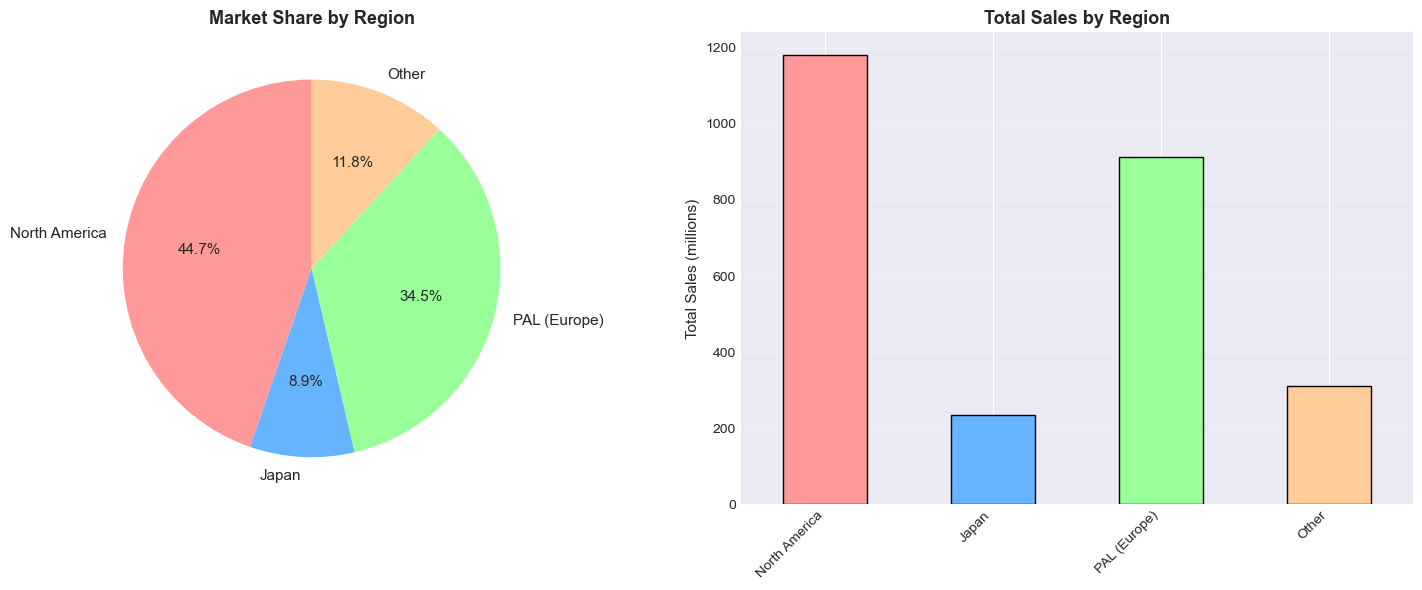

In [13]:
# Visualize regional distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[0].pie(regional_totals, labels=regional_totals.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Market Share by Region', fontsize=13, fontweight='bold')

# Bar chart
regional_totals.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_ylabel('Total Sales (millions)', fontsize=11)
axes[1].set_title('Total Sales by Region', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



### 1.5 Temporal Analysis



In [14]:
# Extract year from release_date
df_time = df_sales[df_sales['release_date'].notna()].copy()
df_time['year'] = df_time['release_date'].dt.year
df_time['month'] = df_time['release_date'].dt.month

# Filter reasonable years (1980-2024)
df_time = df_time[(df_time['year'] >= 1980) & (df_time['year'] <= 2024)]

print(f"Games with valid release dates: {len(df_time):,}")
print(f"Year range: {df_time['year'].min()} - {df_time['year'].max()}")



Games with valid release dates: 18,821
Year range: 1980 - 2020


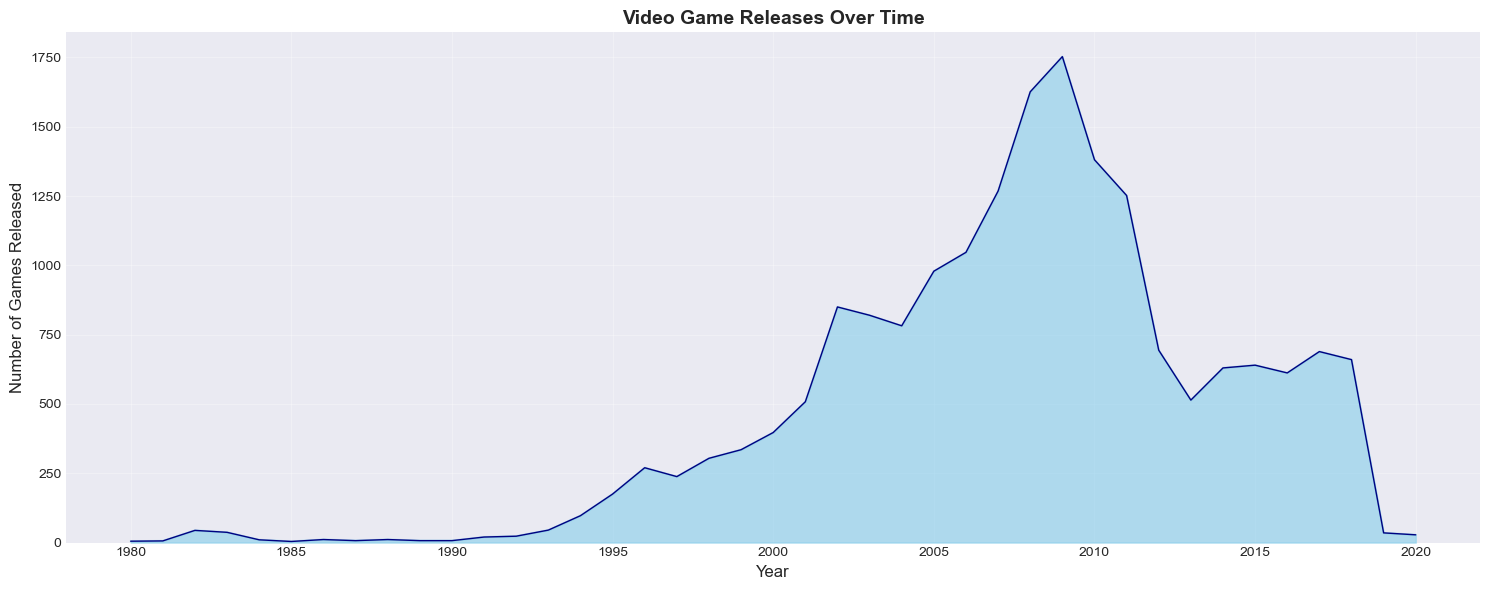


Peak year: 2009 with 1,753 games


In [16]:
# Games released per year
games_per_year = df_time.groupby('year').size()

fig, ax = plt.subplots(figsize=(15, 6))
# Changed: Removed 'edgecolor' parameter and added proper edge styling
games_per_year.plot(kind='area', ax=ax, color='skyblue', alpha=0.6)
# If you want an edge color, add a line plot on top
ax.plot(games_per_year.index, games_per_year.values, color='navy', linewidth=1)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Games Released', fontsize=12)
ax.set_title('Video Game Releases Over Time', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPeak year: {games_per_year.idxmax()} with {games_per_year.max():,} games")


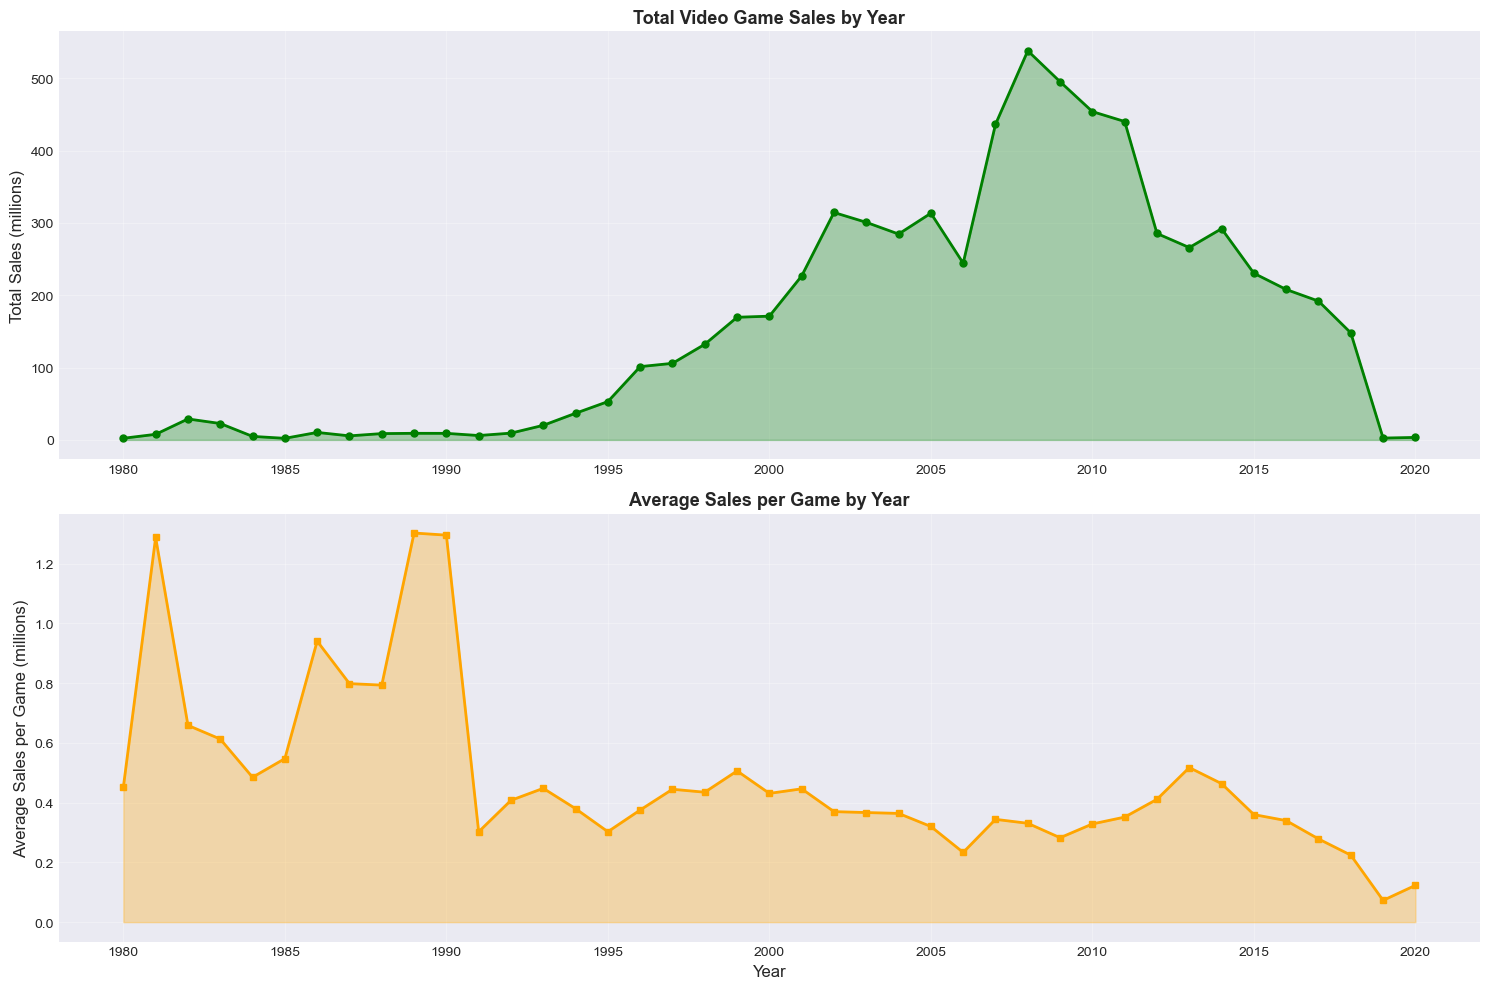

In [17]:
# Sales trends over time
sales_by_year = df_time.groupby('year')['total_sales(mil)'].agg(['sum', 'mean', 'count'])

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Total sales per year
axes[0].plot(sales_by_year.index, sales_by_year['sum'], marker='o', linewidth=2, markersize=5, color='green')
axes[0].fill_between(sales_by_year.index, sales_by_year['sum'], alpha=0.3, color='green')
axes[0].set_ylabel('Total Sales (millions)', fontsize=12)
axes[0].set_title('Total Video Game Sales by Year', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Average sales per game
axes[1].plot(sales_by_year.index, sales_by_year['mean'], marker='s', linewidth=2, markersize=5, color='orange')
axes[1].fill_between(sales_by_year.index, sales_by_year['mean'], alpha=0.3, color='orange')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Average Sales per Game (millions)', fontsize=12)
axes[1].set_title('Average Sales per Game by Year', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



### 1.6 Console Analysis



In [18]:
# Console statistics
console_stats = df_sales.groupby('console').agg({
    'title': 'count',
    'total_sales(mil)': ['sum', 'mean', 'max']
}).round(2)

console_stats.columns = ['Game_Count', 'Total_Sales', 'Avg_Sales', 'Best_Game_Sales']
console_stats = console_stats.sort_values('Total_Sales', ascending=False)

print("Top 20 Consoles by Total Sales:")
print("=" * 80)
print(console_stats.head(20))



Top 20 Consoles by Total Sales:
         Game_Count  Total_Sales  Avg_Sales  Best_Game_Sales
console                                                     
PS2            2126      1027.76       0.48            16.15
X360           1302       859.79       0.66            15.86
PS3            1348       839.70       0.62            20.32
PS             1130       546.25       0.48             6.27
PS4             908       539.92       0.59            19.39
Wii            1357       459.44       0.34             6.89
DS             2396       458.17       0.19             5.66
XOne            524       268.96       0.51             8.72
PSP            1340       245.29       0.18             7.72
XB              836       232.05       0.28             3.02
GBA             899       224.48       0.25             4.24
PC             1560       168.99       0.11             7.96
GC              528       119.53       0.23             1.90
3DS             562        99.27       0.18          

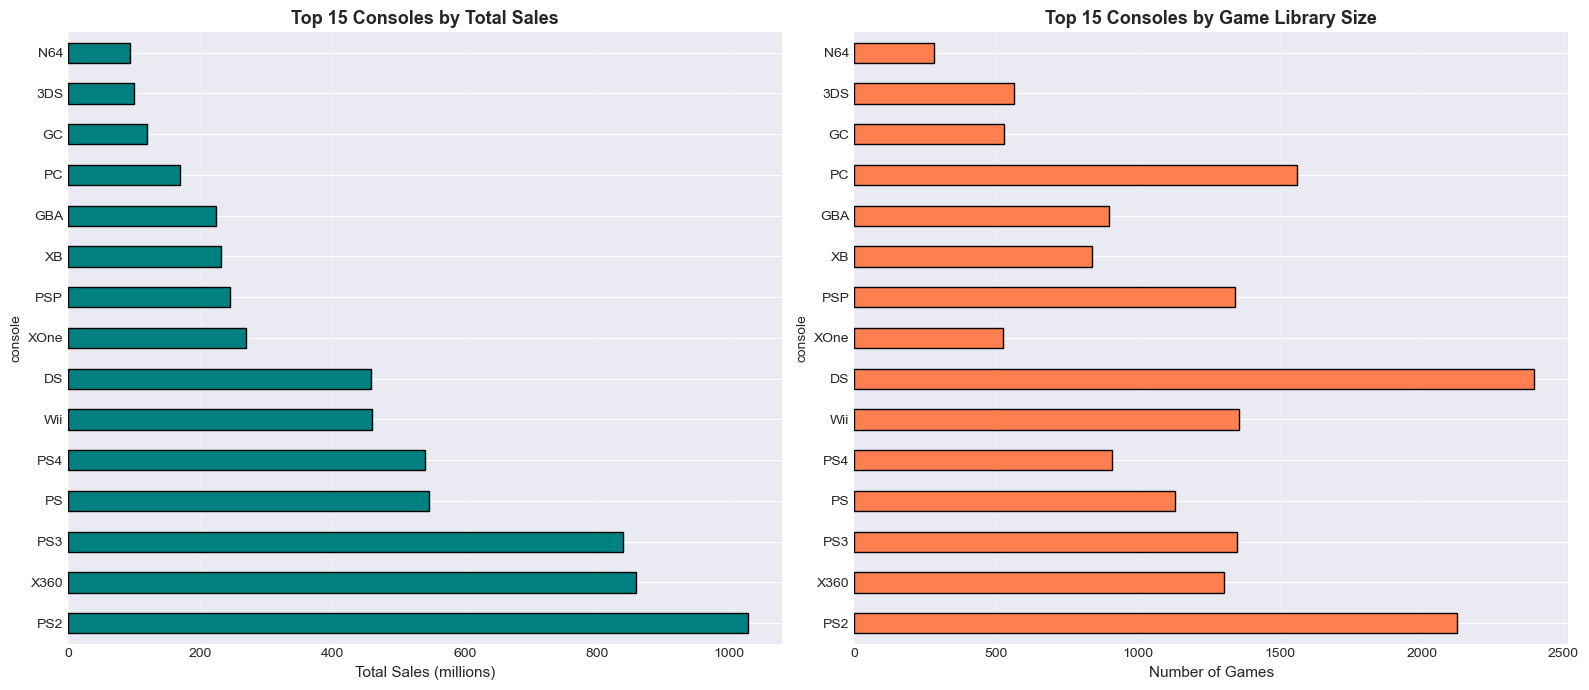

In [19]:
# Top 15 consoles visualization
top_consoles = console_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Total sales
top_consoles['Total_Sales'].plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_xlabel('Total Sales (millions)', fontsize=11)
axes[0].set_title('Top 15 Consoles by Total Sales', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Number of games
top_consoles['Game_Count'].plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Number of Games', fontsize=11)
axes[1].set_title('Top 15 Consoles by Game Library Size', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



### 1.7 Genre Analysis



In [20]:
# Genre statistics
genre_stats = df_sales.groupby('genre').agg({
    'title': 'count',
    'total_sales(mil)': ['sum', 'mean', 'median']
}).round(2)

genre_stats.columns = ['Game_Count', 'Total_Sales', 'Avg_Sales', 'Median_Sales']
genre_stats = genre_stats.sort_values('Total_Sales', ascending=False)

print("Genre Statistics:")
print("=" * 80)
print(genre_stats)



Genre Statistics:
                  Game_Count  Total_Sales  Avg_Sales  Median_Sales
genre                                                             
Sports                  2597      1187.51       0.46          0.20
Action                  2839      1125.89       0.40          0.14
Shooter                 1485       995.50       0.67          0.18
Misc                    2004       557.79       0.28          0.10
Racing                  1431       525.75       0.37          0.14
Role-Playing            1491       426.80       0.29          0.11
Platform                 951       349.15       0.37          0.17
Fighting                 871       341.13       0.39          0.16
Adventure               1893       325.39       0.17          0.04
Simulation              1121       300.65       0.27          0.08
Action-Adventure         264       148.52       0.56          0.22
Puzzle                   723       127.28       0.18          0.06
Strategy                 820       118.31   

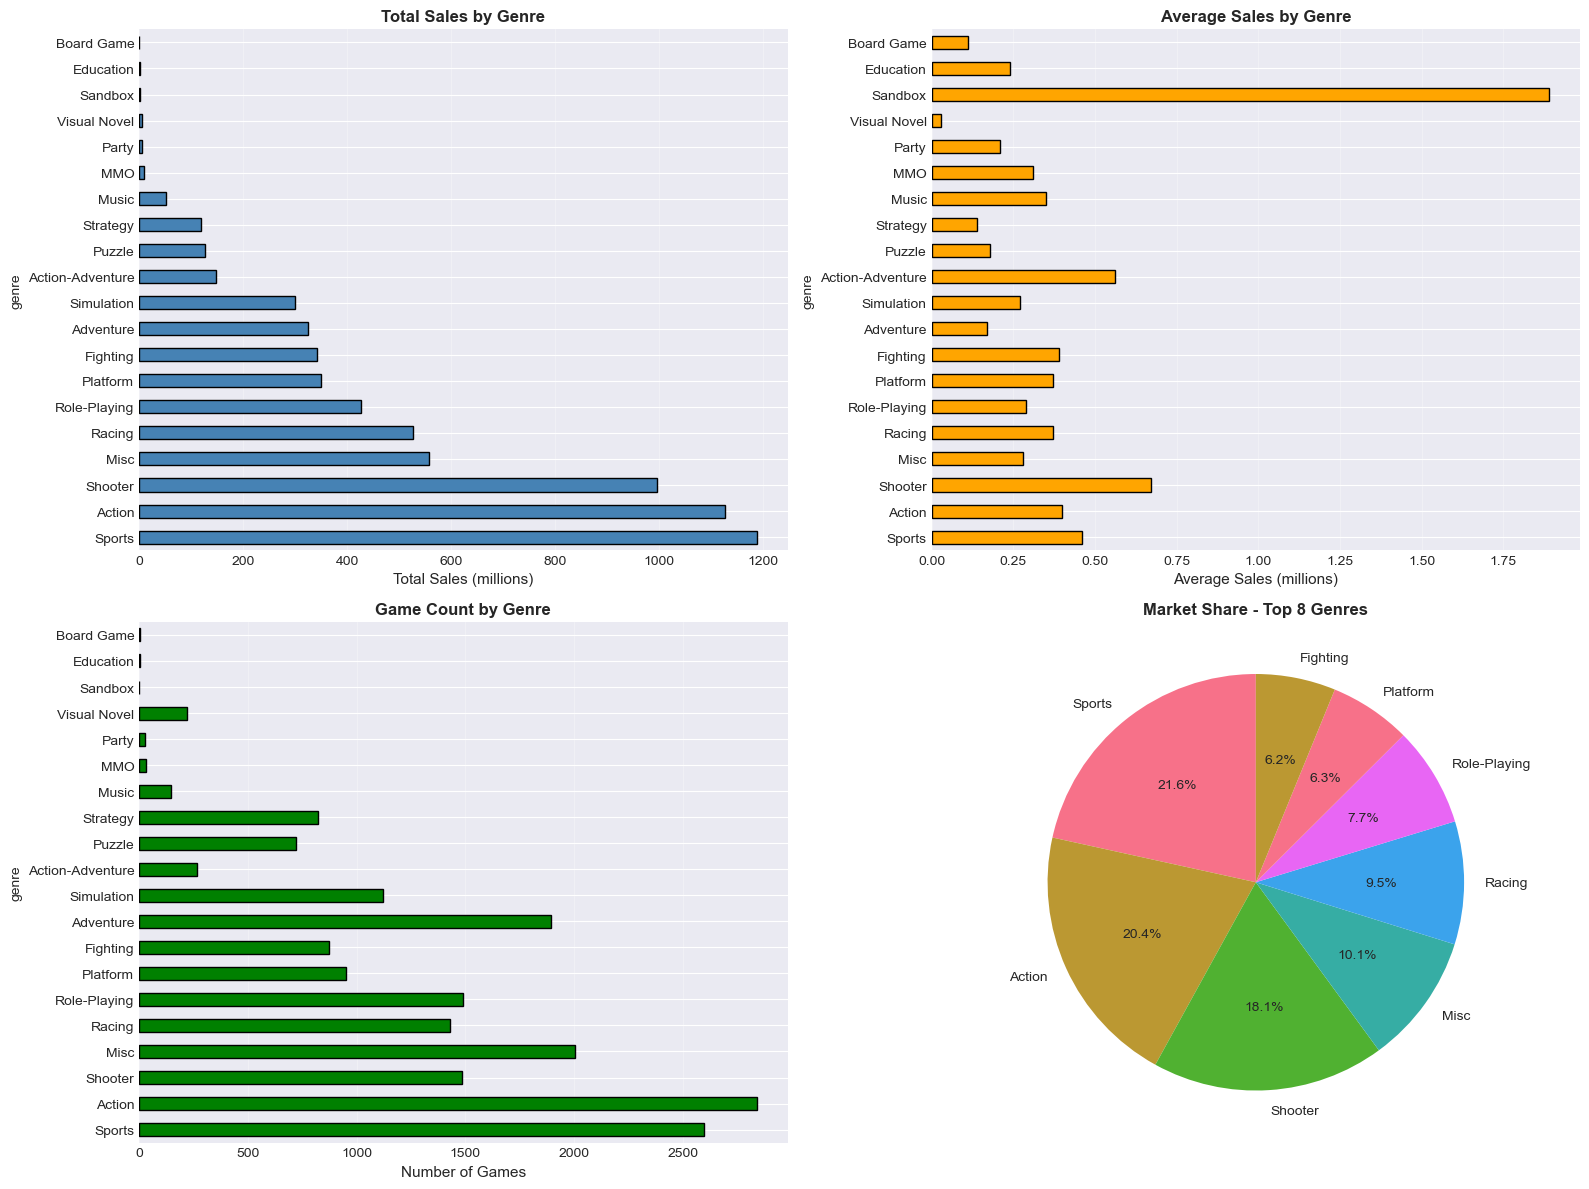

In [21]:
# Visualize genre performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total sales by genre
genre_stats['Total_Sales'].plot(kind='barh', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Total Sales (millions)', fontsize=11)
axes[0, 0].set_title('Total Sales by Genre', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Average sales by genre
genre_stats['Avg_Sales'].plot(kind='barh', ax=axes[0, 1], color='orange', edgecolor='black')
axes[0, 1].set_xlabel('Average Sales (millions)', fontsize=11)
axes[0, 1].set_title('Average Sales by Genre', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Number of games by genre
genre_stats['Game_Count'].plot(kind='barh', ax=axes[1, 0], color='green', edgecolor='black')
axes[1, 0].set_xlabel('Number of Games', fontsize=11)
axes[1, 0].set_title('Game Count by Genre', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Genre distribution - pie chart
top_genres = genre_stats['Total_Sales'].head(8)
axes[1, 1].pie(top_genres, labels=top_genres.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Market Share - Top 8 Genres', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



### 1.8 Critic Score Analysis



In [22]:
# Analyze games with critic scores
df_scored = df[(df['critic_score'].notna()) & (df['total_sales(mil)'].notna())]

print(f"Games with both Critic Score and Sales Data: {len(df_scored):,}")
print(f"\nCritic Score Statistics:")
print(df_scored['critic_score'].describe())



Games with both Critic Score and Sales Data: 4,126

Critic Score Statistics:
count   4126.00
mean       7.10
std        1.44
min        1.00
25%        6.30
50%        7.30
75%        8.10
max       10.00
Name: critic_score, dtype: float64


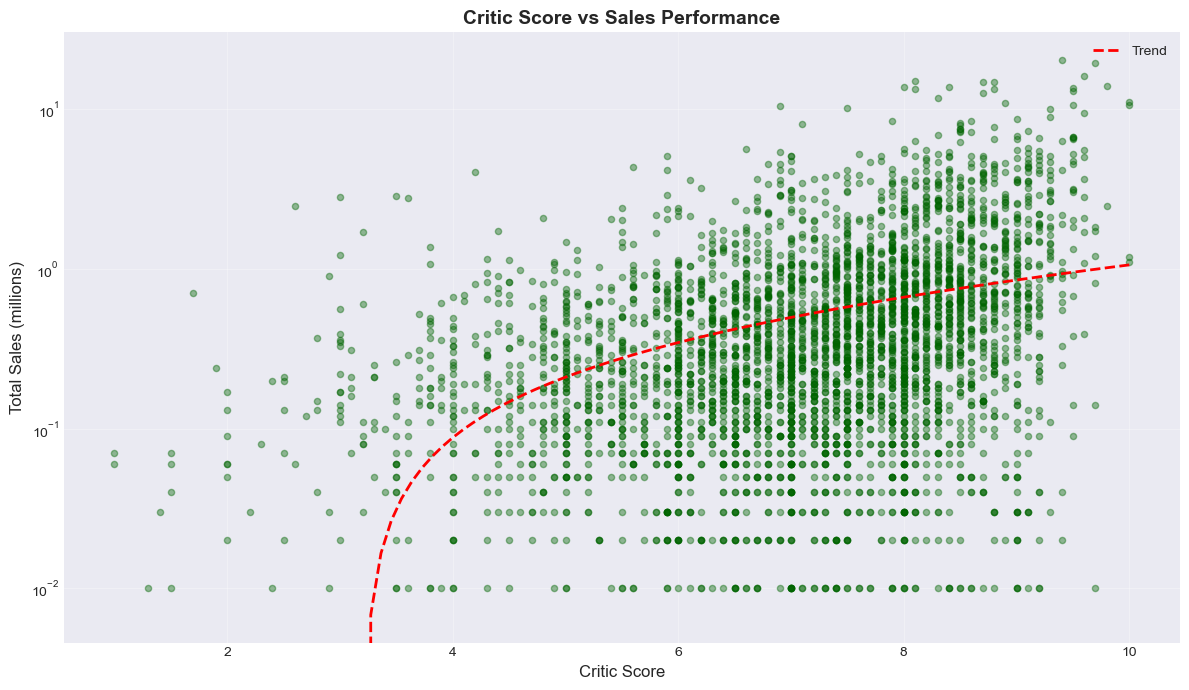


Correlation between Critic Score and Sales: 0.281


In [23]:
# Relationship between critic score and sales
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(df_scored['critic_score'], df_scored['total_sales(mil)'], 
           alpha=0.4, s=20, color='darkgreen')
ax.set_xlabel('Critic Score', fontsize=12)
ax.set_ylabel('Total Sales (millions)', fontsize=12)
ax.set_title('Critic Score vs Sales Performance', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(alpha=0.3)

# Add trend line
z = np.polyfit(df_scored['critic_score'], np.log1p(df_scored['total_sales(mil)']), 1)
p = np.poly1d(z)
x_trend = np.linspace(df_scored['critic_score'].min(), df_scored['critic_score'].max(), 100)
ax.plot(x_trend, np.exp(p(x_trend))-1, "r--", linewidth=2, label='Trend')
ax.legend()

plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df_scored[['critic_score', 'total_sales(mil)']].corr().iloc[0, 1]
print(f"\nCorrelation between Critic Score and Sales: {correlation:.3f}")



### 1.9 Key Insights Summary



In [24]:
print("="*80)
print("KEY FINDINGS - VIDEO GAME SALES EXPLORATORY DATA ANALYSIS")
print("="*80)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total records: {len(df):,}")
print(f"  • Records with sales data: {len(df_sales):,} ({len(df_sales)/len(df)*100:.1f}%)")
print(f"  • Time period: {df_time['year'].min()}-{df_time['year'].max()}")

print("\n💰 SALES INSIGHTS:")
print(f"  • Total market sales: {df_sales['total_sales(mil)'].sum():,.2f} million units")
print(f"  • Average game sales: {df_sales['total_sales(mil)'].mean():.2f} million")
print(f"  • Median game sales: {df_sales['total_sales(mil)'].median():.2f} million")

print("\n🌍 REGIONAL INSIGHTS:")
if len(df_regional) > 0:
    print(f"  • North America: {regional_totals['North America']:,.2f}M ({regional_totals['North America']/regional_totals.sum()*100:.1f}%)")
    print(f"  • Japan: {regional_totals['Japan']:,.2f}M ({regional_totals['Japan']/regional_totals.sum()*100:.1f}%)")
    print(f"  • PAL (Europe): {regional_totals['PAL (Europe)']:,.2f}M ({regional_totals['PAL (Europe)']/regional_totals.sum()*100:.1f}%)")

print("\n🎮 CONSOLE INSIGHTS:")
print(f"  • Total unique consoles: {df['console'].nunique()}")
print(f"  • Top console by sales: {console_stats.index[0]} ({console_stats.iloc[0]['Total_Sales']:.2f}M)")

print("\n🎯 GENRE INSIGHTS:")
print(f"  • Total unique genres: {df['genre'].nunique()}")
print(f"  • Top genre by sales: {genre_stats.index[0]} ({genre_stats.iloc[0]['Total_Sales']:.2f}M)")

print("\n✅ Analysis Complete!")
print("="*80)

print("\n")
print("Save this output for your thesis!")
print("Next step: Run 02_preprocessing.ipynb")


KEY FINDINGS - VIDEO GAME SALES EXPLORATORY DATA ANALYSIS

📊 DATASET OVERVIEW:
  • Total records: 64,016
  • Records with sales data: 18,922 (29.6%)
  • Time period: 1980-2020

💰 SALES INSIGHTS:
  • Total market sales: 6,605.91 million units
  • Average game sales: 0.35 million
  • Median game sales: 0.12 million

🌍 REGIONAL INSIGHTS:
  • North America: 1,181.10M (44.7%)
  • Japan: 235.97M (8.9%)
  • PAL (Europe): 911.61M (34.5%)

🎮 CONSOLE INSIGHTS:
  • Total unique consoles: 81
  • Top console by sales: PS2 (1027.76M)

🎯 GENRE INSIGHTS:
  • Total unique genres: 20
  • Top genre by sales: Sports (1187.51M)

✅ Analysis Complete!


Save this output for your thesis!
Next step: Run 02_preprocessing.ipynb


## Stage 2: Data Preprocessing and Feature Engineering

Transform raw game records into a clean, model-ready dataset and define all feature groups.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import json
import re
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries loaded")



✓ Libraries loaded


### 2.1 Load Raw Data



In [3]:
df = pd.read_excel('VideoGames_Sales.xlsx')
print(f"Original dataset shape: {df.shape}")



Original dataset shape: (64016, 12)


### 2.2 Missing Data Strategy



In [4]:
print("Missing Data Strategy:")
print("=" * 60)
print("1. Keep records with total_sales (target variable)")
print("2. Keep records with release_date (temporal features)")
print("3. Keep categorical features (console, genre, publisher)")
print("4. Critic_score: Keep as optional feature (impute for missing)")

# Filter for records with sales data
df_clean = df[df['total_sales(mil)'].notna()].copy()
print(f"\nAfter filtering for sales data: {len(df_clean):,} records")

# Filter for records with release date
df_clean = df_clean[df_clean['release_date'].notna()].copy()
print(f"After filtering for release date: {len(df_clean):,} records")

# Remove rows with missing essential categoricals
essential_cols = ['console', 'genre', 'publisher']
df_clean = df_clean.dropna(subset=essential_cols)
print(f"After filtering essential categoricals: {len(df_clean):,} records")



Missing Data Strategy:
1. Keep records with total_sales (target variable)
2. Keep records with release_date (temporal features)
3. Keep categorical features (console, genre, publisher)
4. Critic_score: Keep as optional feature (impute for missing)

After filtering for sales data: 18,922 records
After filtering for release date: 18,832 records
After filtering essential categoricals: 18,832 records


### 2.3 Feature Engineering - Temporal Features



In [5]:
# Extract temporal features
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_month'] = df_clean['release_date'].dt.month
df_clean['release_quarter'] = df_clean['release_date'].dt.quarter
df_clean['release_day_of_year'] = df_clean['release_date'].dt.dayofyear

# Calculate game age
reference_year = 2024
df_clean['game_age'] = reference_year - df_clean['release_year']

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_clean['release_season'] = df_clean['release_month'].apply(get_season)

# Holiday season indicator
df_clean['is_holiday_release'] = df_clean['release_month'].isin([11, 12]).astype(int)

print("✓ Temporal Features Created")



✓ Temporal Features Created


### 2.4 Feature Engineering - Console Generation



In [6]:
console_generation_map = {
    # Early generations
    'Atari': 'Gen_1-2', '2600': 'Gen_1-2', 'Intellivision': 'Gen_1-2',
    # Generation 3
    'NES': 'Gen_3', 'SMS': 'Gen_3',
    # Generation 4
    'SNES': 'Gen_4', 'GEN': 'Gen_4', 'Genesis': 'Gen_4',
    # Generation 5
    'PS': 'Gen_5', 'N64': 'Gen_5', 'SAT': 'Gen_5',
    # Generation 6
    'PS2': 'Gen_6', 'XB': 'Gen_6', 'GC': 'Gen_6', 'DC': 'Gen_6',
    # Generation 7
    'X360': 'Gen_7', 'PS3': 'Gen_7', 'Wii': 'Gen_7',
    # Generation 8
    'PS4': 'Gen_8', 'XOne': 'Gen_8', 'WiiU': 'Gen_8', 'NS': 'Gen_8',
    # Generation 9
    'PS5': 'Gen_9', 'XSX': 'Gen_9',
    # Handheld
    'GB': 'Handheld_Early', 'GBA': 'Handheld_Early', 'GBC': 'Handheld_Early',
    'DS': 'Handheld_Modern', '3DS': 'Handheld_Modern', 
    'PSP': 'Handheld_Modern', 'PSV': 'Handheld_Modern',
    # Other
    'PC': 'PC', 'iOS': 'Mobile', 'And': 'Mobile'
}

df_clean['console_generation'] = df_clean['console'].map(console_generation_map)
df_clean['console_generation'] = df_clean['console_generation'].fillna('Other')

print("✓ Console Generation Features Created")



✓ Console Generation Features Created


### 2.5 Feature Engineering - Text Features



In [8]:
# Title length
df_clean['title_length'] = df_clean['title'].str.len()
df_clean['title_word_count'] = df_clean['title'].str.split().str.len()

# Sequel indicators
sequel_patterns = r'\b(2|3|4|5|II|III|IV|V|VI|VII|VIII|IX|X|sequel|returns|remastered|remake)\b'
# Fix: Fill NaN values with False before converting to int
df_clean['is_sequel'] = df_clean['title'].str.contains(sequel_patterns, case=False, regex=True).fillna(False).astype(int)

# Special edition
special_patterns = r'\b(deluxe|ultimate|gold|platinum|goty|edition|collection|complete)\b'
# Fix: Fill NaN values with False before converting to int
df_clean['is_special_edition'] = df_clean['title'].str.contains(special_patterns, case=False, regex=True).fillna(False).astype(int)

# Online/multiplayer
online_patterns = r'\b(online|multiplayer|mmo|battle royale|versus|vs)\b'
# Fix: Fill NaN values with False before converting to int
df_clean['has_online_indicator'] = df_clean['title'].str.contains(online_patterns, case=False, regex=True).fillna(False).astype(int)

print(f"✓ Text Features Created")
print(f"  • Sequels: {df_clean['is_sequel'].sum():,}")
print(f"  • Special editions: {df_clean['is_special_edition'].sum():,}")

✓ Text Features Created
  • Sequels: 3,109
  • Special editions: 709


### 2.6 Feature Engineering - Publisher Features



In [9]:
# Publisher stats
publisher_stats = df_clean.groupby('publisher')['total_sales(mil)'].agg(['count', 'mean', 'sum'])
publisher_stats.columns = ['publisher_game_count', 'publisher_avg_sales', 'publisher_total_sales']

df_clean = df_clean.merge(publisher_stats, left_on='publisher', right_index=True, how='left')

# Publisher tier
quantiles = df_clean['publisher_total_sales'].quantile([0.33, 0.67])
def categorize_publisher(total_sales):
    if total_sales <= quantiles[0.33]:
        return 'Small'
    elif total_sales <= quantiles[0.67]:
        return 'Medium'
    else:
        return 'Large'

df_clean['publisher_tier'] = df_clean['publisher_total_sales'].apply(categorize_publisher)

print("✓ Publisher Features Created")



✓ Publisher Features Created


### 2.7 Feature Engineering - Genre Features



In [10]:
# Genre stats
genre_stats = df_clean.groupby('genre')['total_sales(mil)'].agg(['mean', 'sum', 'count'])
genre_stats.columns = ['genre_avg_sales', 'genre_total_sales', 'genre_game_count']

df_clean = df_clean.merge(genre_stats, left_on='genre', right_index=True, how='left')

# Popularity index
df_clean['genre_popularity_index'] = (df_clean['genre_total_sales'] / df_clean['genre_total_sales'].max()) * 100

print("✓ Genre Features Created")



✓ Genre Features Created


### 2.8 Handle Critic Score



In [11]:
# Impute with genre median
df_clean['critic_score_imputed'] = df_clean['critic_score'].isna().astype(int)

genre_median_scores = df_clean.groupby('genre')['critic_score'].median()
overall_median = df_clean['critic_score'].median()

df_clean['critic_score_filled'] = df_clean.apply(
    lambda row: row['critic_score'] if pd.notna(row['critic_score']) 
    else genre_median_scores.get(row['genre'], overall_median),
    axis=1
)

print("✓ Critic scores imputed")



✓ Critic scores imputed


### 2.9 Create Target Variables



In [12]:
# Log transformation
df_clean['log_total_sales'] = np.log1p(df_clean['total_sales(mil)'])

# Categories
def categorize_sales(sales):
    if sales < 0.1:
        return 'Very Low'
    elif sales < 0.5:
        return 'Low'
    elif sales < 1.0:
        return 'Medium'
    elif sales < 5.0:
        return 'High'
    else:
        return 'Blockbuster'

df_clean['sales_category'] = df_clean['total_sales(mil)'].apply(categorize_sales)

# Binary
df_clean['is_blockbuster'] = (df_clean['total_sales(mil)'] >= 1.0).astype(int)

print("✓ Target Variables Created")



✓ Target Variables Created


### 2.10 Define Feature Sets



In [13]:
# Categorical features
categorical_features = [
    'console',
    'genre',
    'publisher',
    'console_generation',
    'release_season',
    'publisher_tier'
]

# Numerical features
numerical_features = [
    'release_year',
    'release_month',
    'release_quarter',
    'game_age',
    'critic_score_filled',
    'title_length',
    'title_word_count',
    'publisher_game_count',
    'publisher_avg_sales',
    'genre_avg_sales',
    'genre_popularity_index'
]

# Binary features
binary_features = [
    'is_holiday_release',
    'is_sequel',
    'is_special_edition',
    'has_online_indicator',
    'critic_score_imputed'
]

# All features
all_features = categorical_features + numerical_features + binary_features

# Targets
target_continuous = 'total_sales(mil)'
target_log = 'log_total_sales'
target_multiclass = 'sales_category'
target_binary = 'is_blockbuster'

print(f"Total features: {len(all_features)}")
print(f"  • Categorical: {len(categorical_features)}")
print(f"  • Numerical: {len(numerical_features)}")
print(f"  • Binary: {len(binary_features)}")



Total features: 22
  • Categorical: 6
  • Numerical: 11
  • Binary: 5


### 2.11 Save Processed Data



In [20]:
# Save dataset
output_path = 'C:/Users/tomme/cp-final/video_games_processed.csv'  # Added C: and changed to forward slashes
df_clean.to_csv(output_path, index=False)
print(f"✓ Processed data saved to: {output_path}")

# Save feature config
feature_config = {
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'binary_features': binary_features,
    'all_features': all_features,
    'targets': {
        'continuous': target_continuous,
        'log': target_log,
        'multiclass': target_multiclass,
        'binary': target_binary
    }
}

config_path = '../data/processed/feature_config.json'
with open(config_path, 'w') as f:
    json.dump(feature_config, f, indent=4)
print(f"✓ Feature config saved to: {config_path}")

✓ Processed data saved to: C:/Users/tomme/cp-finalvideo_games_processed.csv
✓ Feature config saved to: ../data/processed/feature_config.json


### 2.12 Summary



In [19]:
print("\n" + "="*60)
print("PREPROCESSING COMPLETE!")
print("="*60)
print(f"\nFinal Dataset Shape: {df_clean.shape}")
print(f"Total Features: {len(all_features)}")
print(f"Total Records: {len(df_clean):,}")
print(f"\n✓ Ready for modeling!")
print("\nNext step: Run 03_modeling_complete.py")
print("="*60)



PREPROCESSING COMPLETE!

Final Dataset Shape: (18832, 38)
Total Features: 22
Total Records: 18,832

✓ Ready for modeling!

Next step: Run 03_modeling_complete.py


## Stage 3: Model Training and Evaluation

Train multiple regression models, tune hyperparameters, evaluate performance, and persist the best model artifacts.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from datetime import datetime

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Model persistence
import joblib

warnings.filterwarnings('ignore')
print("✓ All libraries imported")



✓ All libraries imported


### 3.1 Load Processed Data



In [3]:
df = pd.read_csv('video_games_processed.csv')
print(f"Dataset shape: {df.shape}")

# Load feature configuration
with open('../data/processed/feature_config.json', 'r') as f:
    feature_config = json.load(f)

categorical_features = feature_config['categorical_features']
numerical_features = feature_config['numerical_features']
binary_features = feature_config['binary_features']
all_features = feature_config['all_features']
target = feature_config['targets']['log']  # Use log-transformed target

print(f"Features loaded: {len(all_features)}")
print(f"Target variable: {target}")

Dataset shape: (18832, 38)
Features loaded: 22
Target variable: log_total_sales


### 3.2 Train-Test Split



In [4]:
# Prepare features and target
X = df[all_features].copy()
y = df[target].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"\n✓ Data split completed")
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

Features shape: (18832, 22)
Target shape: (18832,)

✓ Data split completed
Training set: 15,065 samples
Test set: 3,767 samples


### 3.3 Build Preprocessing Pipeline



In [5]:
# Numerical transformer
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical transformer
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop'
)

print("✓ Preprocessing pipeline created")

# Test preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Transformed features: {X_train_transformed.shape[1]}")
print(f"(Increase due to one-hot encoding)")



✓ Preprocessing pipeline created

Original features: 22
Transformed features: 776
(Increase due to one-hot encoding)


### 3.4 Baseline Model - Linear Regression



In [6]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

print("Training Baseline Linear Regression...")

# Add an imputer to the preprocessing pipeline to handle NaN values
# Assuming 'preprocessor' is a ColumnTransformer you've defined earlier
# We'll create a new pipeline that includes imputation
preprocessor_with_imputer = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('imputer', SimpleImputer(strategy='mean'))  # You can choose 'mean', 'median', 'most_frequent', or 'constant'
])

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_with_imputer),
    ('regressor', LinearRegression())
])

baseline_pipeline.fit(X_train, y_train)

y_train_pred_baseline = baseline_pipeline.predict(X_train)
y_test_pred_baseline = baseline_pipeline.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Convert back to original scale
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    
    rmse_original = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
    mae_original = mean_absolute_error(y_true_original, y_pred_original)
    mape = mean_absolute_percentage_error(y_true_original, y_pred_original) * 100
    
    print(f"\n{model_name} - {dataset_name} Set:")
    print("=" * 60)
    print(f"Log-scale: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    print(f"Original-scale: RMSE={rmse_original:.4f}M, MAE={mae_original:.4f}M, MAPE={mape:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'rmse_original': rmse_original, 
            'mae_original': mae_original, 'mape': mape}

baseline_train = evaluate_model(y_train, y_train_pred_baseline, "Linear Regression", "Training")
baseline_test = evaluate_model(y_test, y_test_pred_baseline, "Linear Regression", "Test")

Training Baseline Linear Regression...

Linear Regression - Training Set:
Log-scale: RMSE=0.2439, MAE=0.1594, R²=0.4028
Original-scale: RMSE=0.6932M, MAE=0.2679M, MAPE=3907626058910083.00%

Linear Regression - Test Set:
Log-scale: RMSE=0.2459, MAE=0.1642, R²=0.3834
Original-scale: RMSE=0.7112M, MAE=0.2733M, MAPE=4202272483359638.50%


### 3.5 Model Comparison - Multiple Algorithms



In [7]:
# First, make sure all necessary imports are included
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
# Import any other models you're using

# Define your models dictionary
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),  # Fixed typo in original code
    'AdaBoost': AdaBoostRegressor(random_state=42)
}

# Define preprocessor with proper imputation
# Make sure X_train is defined before this point
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing numeric values with mean
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing categorical values with most frequent
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Create a pipeline that first preprocesses the data (including imputation) then applies the model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Fit the entire pipeline on the training data
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Evaluate model performance
    train_metrics = evaluate_model(y_train, y_train_pred, name, "Training")
    test_metrics = evaluate_model(y_test, y_test_pred, name, "Test")
    
    # Store results
    results[name] = {
        'pipeline': pipeline,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics
    }
    
    print("✓ Complete")

print("\n" + "=" * 80)
print("✓ All models trained")


Training Linear Regression...

Linear Regression - Training Set:
Log-scale: RMSE=0.2441, MAE=0.1604, R²=0.4017
Original-scale: RMSE=0.6937M, MAE=0.2690M, MAPE=4037748536228904.50%

Linear Regression - Test Set:
Log-scale: RMSE=0.2458, MAE=0.1640, R²=0.3838
Original-scale: RMSE=0.7111M, MAE=0.2731M, MAPE=4201203029883798.50%
✓ Complete

Training Random Forest...

Random Forest - Training Set:
Log-scale: RMSE=0.0779, MAE=0.0478, R²=0.9390
Original-scale: RMSE=0.2446M, MAE=0.0869M, MAPE=931486937954300.62%

Random Forest - Test Set:
Log-scale: RMSE=0.2145, MAE=0.1335, R²=0.5309
Original-scale: RMSE=0.6068M, MAE=0.2302M, MAPE=2426568517872607.50%
✓ Complete

Training Gradient Boosting...

Gradient Boosting - Training Set:
Log-scale: RMSE=0.2220, MAE=0.1421, R²=0.5053
Original-scale: RMSE=0.6065M, MAE=0.2412M, MAPE=3219834286330734.00%

Gradient Boosting - Test Set:
Log-scale: RMSE=0.2268, MAE=0.1455, R²=0.4756
Original-scale: RMSE=0.6473M, MAE=0.2474M, MAPE=3231124080931744.00%
✓ Complete

### 3.6 Compare Model Performance



In [8]:
# Create comparison dataframe
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Train_R2': res['train_metrics']['r2'],
        'Test_R2': res['test_metrics']['r2'],
        'Train_RMSE': res['train_metrics']['rmse_original'],
        'Test_RMSE': res['test_metrics']['rmse_original'],
        'Test_MAE': res['test_metrics']['mae_original'],
        'Test_MAPE': res['test_metrics']['mape'],
        'Overfit_Gap': res['train_metrics']['r2'] - res['test_metrics']['r2']
    }
    for name, res in results.items()
]).sort_values('Test_R2', ascending=False)

print("\nModel Performance Comparison:")
print("=" * 120)
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"Test R² = {comparison_df.iloc[0]['Test_R2']:.4f}")




Model Performance Comparison:
            Model  Train_R2   Test_R2  Train_RMSE  Test_RMSE  Test_MAE    Test_MAPE  Overfit_Gap
    Random Forest  0.939029  0.530888    0.244599   0.606798  0.230176 2.426569e+15     0.408142
Gradient Boosting  0.505270  0.475574    0.606513   0.647346  0.247381 3.231124e+15     0.029696
Linear Regression  0.401704  0.383843    0.693653   0.711092  0.273078 4.201203e+15     0.017861
         AdaBoost  0.020277 -0.037620    0.668221   0.741319  0.405993 1.069699e+16     0.057897

🏆 Best Model: Random Forest
Test R² = 0.5309


### 3.7 Visualize Model Comparison



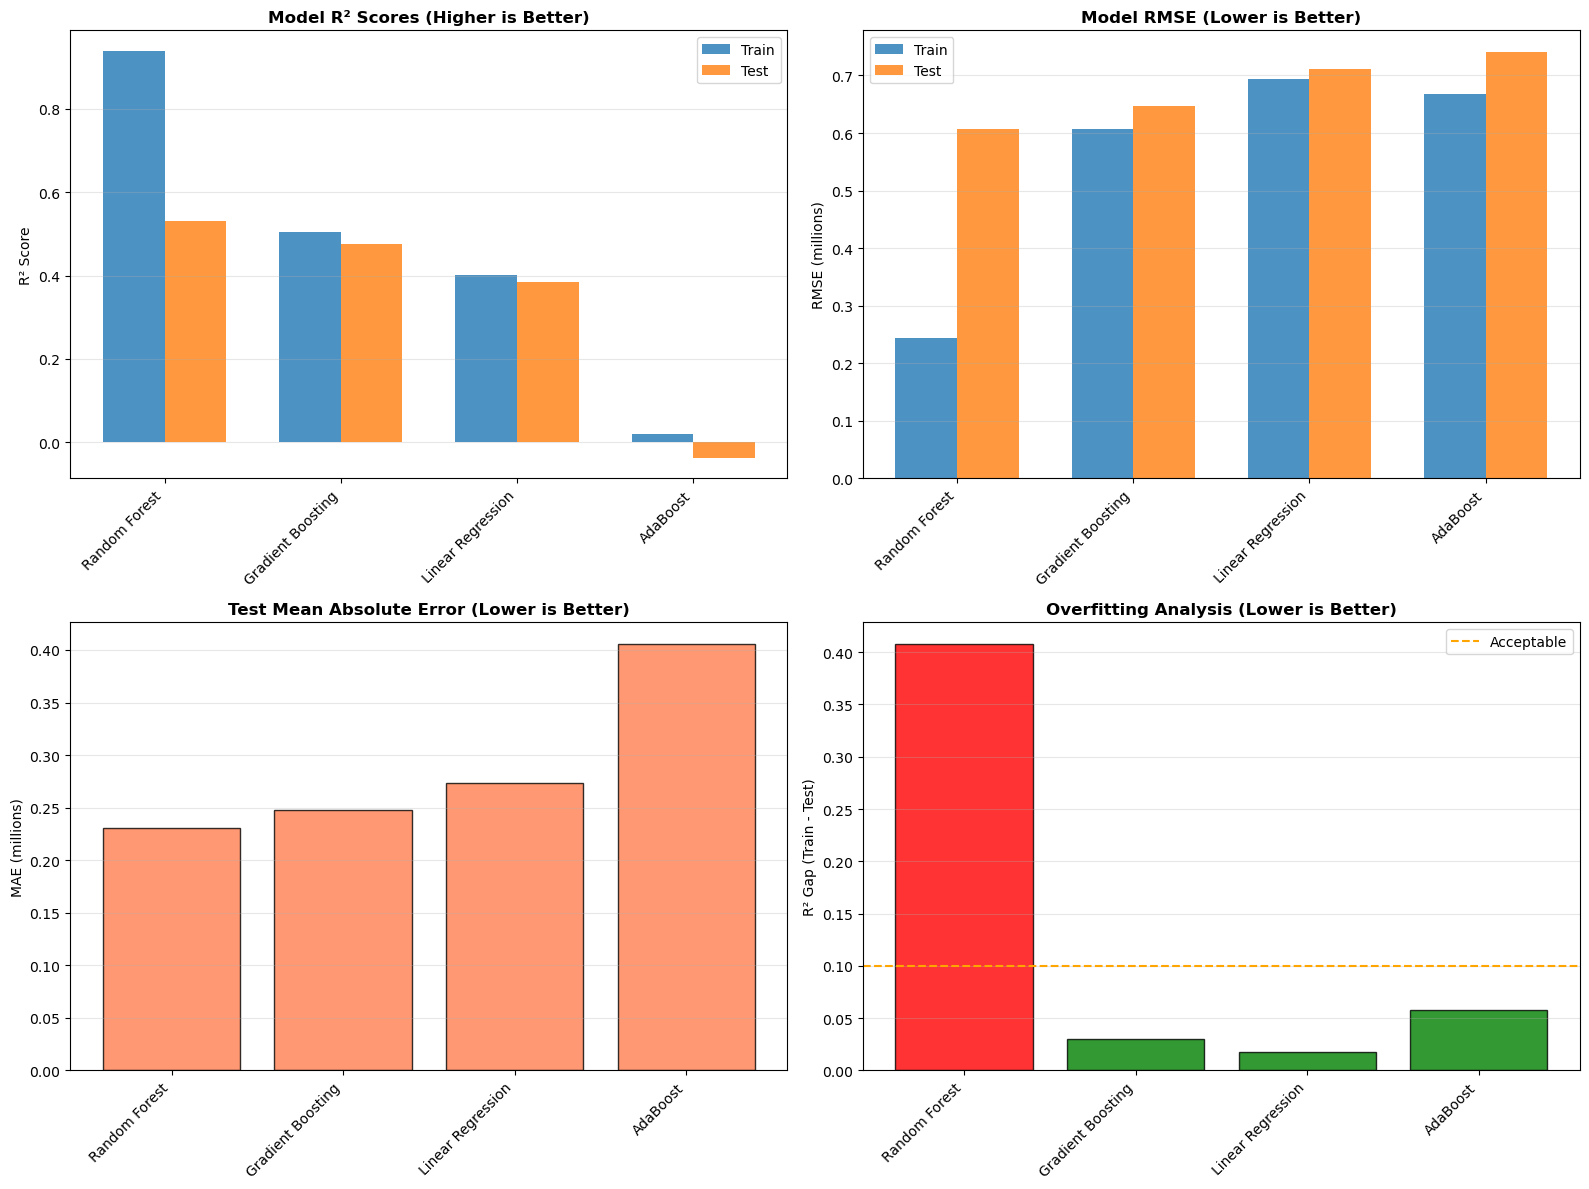

✓ Model comparison plot saved


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² scores
x = np.arange(len(comparison_df))
width = 0.35
axes[0, 0].bar(x - width/2, comparison_df['Train_R2'], width, label='Train', alpha=0.8)
axes[0, 0].bar(x + width/2, comparison_df['Test_R2'], width, label='Test', alpha=0.8)
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Model R² Scores (Higher is Better)', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. RMSE
axes[0, 1].bar(x - width/2, comparison_df['Train_RMSE'], width, label='Train', alpha=0.8)
axes[0, 1].bar(x + width/2, comparison_df['Test_RMSE'], width, label='Test', alpha=0.8)
axes[0, 1].set_ylabel('RMSE (millions)')
axes[0, 1].set_title('Model RMSE (Lower is Better)', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. MAE
axes[1, 0].bar(x, comparison_df['Test_MAE'], color='coral', alpha=0.8, edgecolor='black')
axes[1, 0].set_ylabel('MAE (millions)')
axes[1, 0].set_title('Test Mean Absolute Error (Lower is Better)', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Overfitting gap
colors = ['green' if gap < 0.1 else 'orange' if gap < 0.2 else 'red' for gap in comparison_df['Overfit_Gap']]
axes[1, 1].bar(x, comparison_df['Overfit_Gap'], color=colors, alpha=0.8, edgecolor='black')
axes[1, 1].set_ylabel('R² Gap (Train - Test)')
axes[1, 1].set_title('Overfitting Analysis (Lower is Better)', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1, 1].axhline(y=0.1, color='orange', linestyle='--', label='Acceptable')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison plot saved")



### 3.8 Hyperparameter Tuning - Random Forest



In [10]:
print("\nStarting Hyperparameter Tuning for Random Forest...")

# Parameter grid
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 20, 30, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None]
}

print(f"Parameter combinations: {np.prod([len(v) for v in param_grid.values()])}")
print("Using RandomizedSearchCV with 20 iterations...")

# Create base pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Randomized search
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nStarting hyperparameter search (this may take 10-20 minutes)...")
random_search.fit(X_train, y_train)

print("\n✓ Hyperparameter tuning complete!")
print(f"\nBest parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV R² score: {random_search.best_score_:.4f}")




Starting Hyperparameter Tuning for Random Forest...
Parameter combinations: 324
Using RandomizedSearchCV with 20 iterations...

Starting hyperparameter search (this may take 10-20 minutes)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Hyperparameter tuning complete!

Best parameters:
  regressor__n_estimators: 300
  regressor__min_samples_split: 2
  regressor__min_samples_leaf: 1
  regressor__max_features: None
  regressor__max_depth: 20

Best CV R² score: 0.5552


### 3.9 Evaluate Best Model



In [11]:
# Get best model
best_rf_model = random_search.best_estimator_

# Predictions
y_train_pred_tuned = best_rf_model.predict(X_train)
y_test_pred_tuned = best_rf_model.predict(X_test)

# Evaluate
tuned_train = evaluate_model(y_train, y_train_pred_tuned, "Tuned Random Forest", "Training")
tuned_test = evaluate_model(y_test, y_test_pred_tuned, "Tuned Random Forest", "Test")

# Compare with baseline
print("\n" + "=" * 80)
print("BEFORE vs AFTER Tuning:")
print("=" * 80)
print(f"Baseline RF Test R²: {results['Random Forest']['test_metrics']['r2']:.4f}")
print(f"Tuned RF Test R²:    {tuned_test['r2']:.4f}")
print(f"Improvement:         +{tuned_test['r2'] - results['Random Forest']['test_metrics']['r2']:.4f}")




Tuned Random Forest - Training Set:
Log-scale: RMSE=0.0914, MAE=0.0595, R²=0.9161
Original-scale: RMSE=0.2621M, MAE=0.1034M, MAPE=1192345646653758.50%

Tuned Random Forest - Test Set:
Log-scale: RMSE=0.2132, MAE=0.1328, R²=0.5364
Original-scale: RMSE=0.6019M, MAE=0.2283M, MAPE=2459875199532950.50%

BEFORE vs AFTER Tuning:
Baseline RF Test R²: 0.5309
Tuned RF Test R²:    0.5364
Improvement:         +0.0055


### 3.10 Feature Importance Analysis



In [12]:
# Get feature names
num_feature_names = numerical_features
cat_encoder = best_rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
bin_feature_names = binary_features
all_feature_names = num_feature_names + cat_feature_names + bin_feature_names

# Get importances
rf_model = best_rf_model.named_steps['regressor']
feature_importances = rf_model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print("=" * 80)
print(importance_df.head(20).to_string(index=False))




Top 20 Most Important Features:
               feature  importance
   publisher_avg_sales    0.241245
   critic_score_filled    0.142535
          title_length    0.075432
          release_year    0.045930
              game_age    0.041403
      title_word_count    0.031858
         release_month    0.030323
       genre_avg_sales    0.027383
  publisher_game_count    0.021571
genre_popularity_index    0.019842
           console_SCD    0.019287
  publisher_tier_Large    0.018530
           console_PSV    0.017747
           console_PS3    0.016479
            console_DS    0.015796
 console_generation_PC    0.014974
           console_3DO    0.011292
       release_quarter    0.010835
 publisher_tier_Medium    0.008558
 release_season_Summer    0.008031


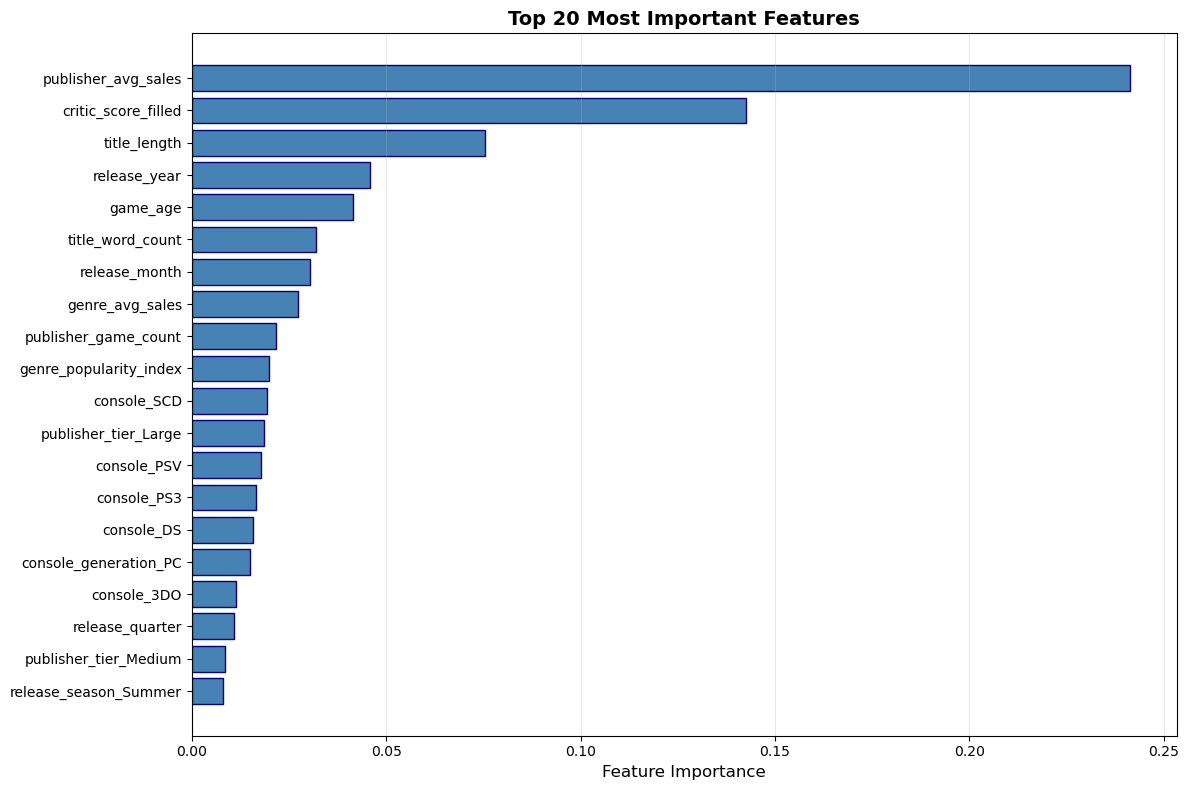

✓ Feature importance plot saved


In [13]:
# Visualize top 20
top_20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top_20))
ax.barh(y_pos, top_20['importance'], color='steelblue', edgecolor='navy')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_20['feature'])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance plot saved")



### 3.11 Prediction Visualization



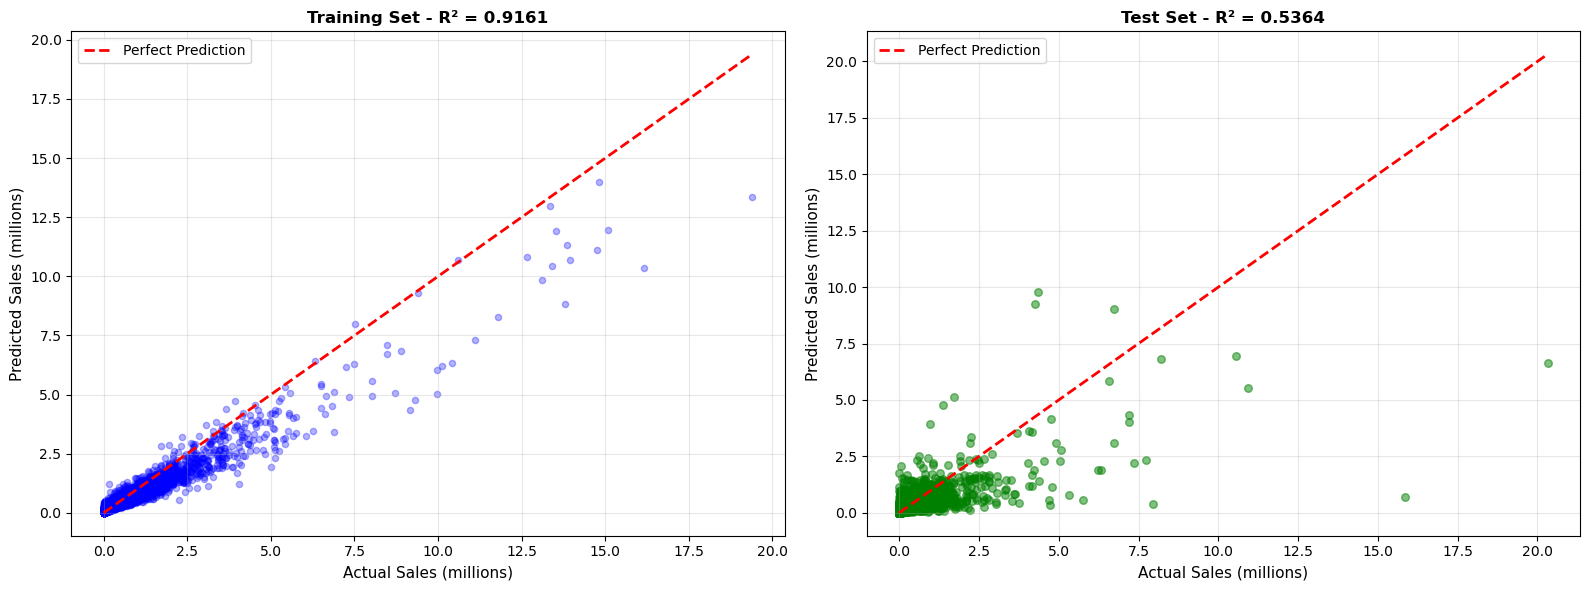

✓ Prediction plots saved


In [14]:
# Convert to original scale
y_train_actual_orig = np.expm1(y_train)
y_test_actual_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_tuned)
y_test_pred_orig = np.expm1(y_test_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train_actual_orig, y_train_pred_orig, alpha=0.3, s=20, color='blue')
axes[0].plot([0, y_train_actual_orig.max()], [0, y_train_actual_orig.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales (millions)', fontsize=11)
axes[0].set_ylabel('Predicted Sales (millions)', fontsize=11)
axes[0].set_title(f'Training Set - R² = {tuned_train["r2"]:.4f}', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test set
axes[1].scatter(y_test_actual_orig, y_test_pred_orig, alpha=0.5, s=30, color='green')
axes[1].plot([0, y_test_actual_orig.max()], [0, y_test_actual_orig.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Sales (millions)', fontsize=11)
axes[1].set_ylabel('Predicted Sales (millions)', fontsize=11)
axes[1].set_title(f'Test Set - R² = {tuned_test["r2"]:.4f}', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Prediction plots saved")



### 3.12 Cross-Validation



In [15]:
print("\nPerforming 5-fold cross-validation...")

cv_scores = cross_val_score(
    best_rf_model, X_train, y_train, 
    cv=5, scoring='r2', n_jobs=-1
)

print("\nCross-Validation R² Scores:")
print("=" * 60)
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV Score: {cv_scores.mean():.4f}")
print(f"Std Dev:       {cv_scores.std():.4f}")
print(f"95% CI:        [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")




Performing 5-fold cross-validation...

Cross-Validation R² Scores:
Fold 1: 0.5492
Fold 2: 0.5428
Fold 3: 0.5438
Fold 4: 0.5364
Fold 5: 0.6036

Mean CV Score: 0.5552
Std Dev:       0.0246
95% CI:        [0.5070, 0.6033]


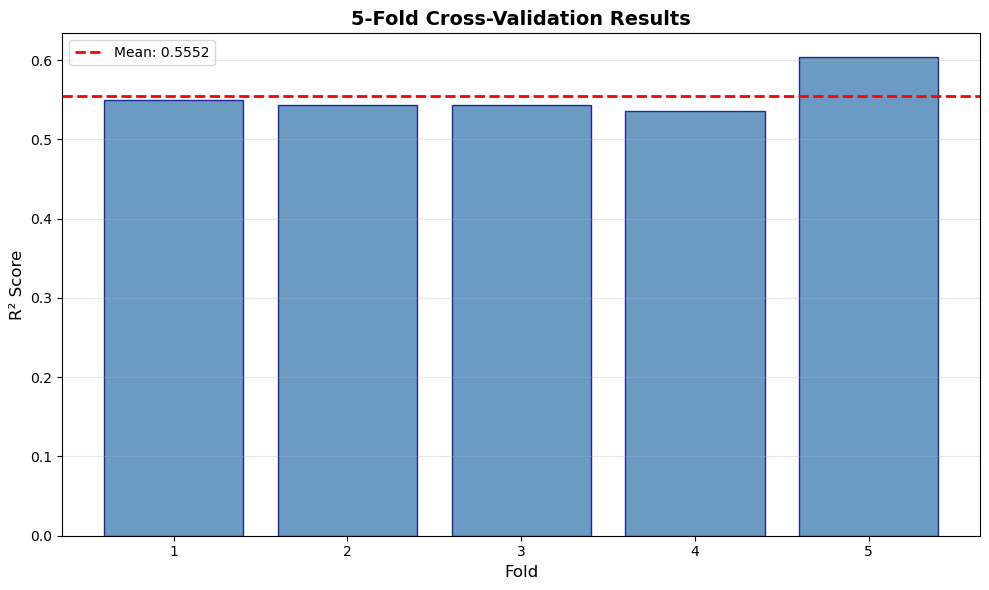

✓ CV plot saved


In [16]:
# Visualize CV scores
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='navy', alpha=0.8)
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 6))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ CV plot saved")



### 3.13 Save Final Model



In [18]:
import os

# Create directory if it doesn't exist
os.makedirs('../models/trained_models/', exist_ok=True)

# Save model
model_path = '../models/trained_models/best_rf_model.pkl'
joblib.dump(best_rf_model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save feature names
feature_names_path = '../models/trained_models/feature_names.pkl'
joblib.dump(all_feature_names, feature_names_path)
print(f"✓ Feature names saved")

# Save feature importance
importance_path = '../models/trained_models/feature_importance.csv'
importance_df.to_csv(importance_path, index=False)
print(f"✓ Feature importance saved")

# Save metadata
model_metadata = {
    'model_type': 'Random Forest Regressor',
    'best_params': random_search.best_params_,
    'train_r2': float(tuned_train['r2']),
    'test_r2': float(tuned_test['r2']),
    'test_rmse': float(tuned_test['rmse_original']),
    'test_mae': float(tuned_test['mae_original']),
    'test_mape': float(tuned_test['mape']),
    'cv_mean_r2': float(cv_scores.mean()),
    'cv_std_r2': float(cv_scores.std()),
    'n_features': len(all_feature_names),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'training_samples': int(len(X_train)),
    'test_samples': int(len(X_test))
}

metadata_path = '../models/trained_models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=4)
print(f"✓ Metadata saved")

✓ Model saved to: ../models/trained_models/best_rf_model.pkl
✓ Feature names saved
✓ Feature importance saved
✓ Metadata saved


### 3.14 Final Summary



In [19]:
print("\n" + "="*80)
print("MODEL TRAINING COMPLETE!")
print("="*80)

print(f"\n📊 FINAL MODEL: Tuned Random Forest Regressor")
print(f"\n🎯 PERFORMANCE METRICS:")
print(f"  Training R²:   {tuned_train['r2']:.4f}")
print(f"  Test R²:       {tuned_test['r2']:.4f}")
print(f"  CV Mean R²:    {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

print(f"\n📏 ERROR METRICS:")
print(f"  Test RMSE:  {tuned_test['rmse_original']:.4f} million units")
print(f"  Test MAE:   {tuned_test['mae_original']:.4f} million units")
print(f"  Test MAPE:  {tuned_test['mape']:.2f}%")

print(f"\n📈 TOP 5 FEATURES:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['feature']:40s} {row['importance']:.4f}")

print(f"\n💾 SAVED FILES:")
print(f"  • {model_path}")
print(f"  • {importance_path}")
print(f"  • {metadata_path}")

print("\n✓ Model is ready for deployment!")
print("Next step: Test the Streamlit app with: streamlit run app/streamlit_app.py")
print("="*80)



MODEL TRAINING COMPLETE!

📊 FINAL MODEL: Tuned Random Forest Regressor

🎯 PERFORMANCE METRICS:
  Training R²:   0.9161
  Test R²:       0.5364
  CV Mean R²:    0.5552 (±0.0246)

📏 ERROR METRICS:
  Test RMSE:  0.6019 million units
  Test MAE:   0.2283 million units
  Test MAPE:  2459875199532950.50%

📈 TOP 5 FEATURES:
  9. publisher_avg_sales                      0.2412
  5. critic_score_filled                      0.1425
  6. title_length                             0.0754
  1. release_year                             0.0459
  4. game_age                                 0.0414

💾 SAVED FILES:
  • ../models/trained_models/best_rf_model.pkl
  • ../models/trained_models/feature_importance.csv
  • ../models/trained_models/model_metadata.json

✓ Model is ready for deployment!
Next step: Test the Streamlit app with: streamlit run app/streamlit_app.py


## Stage 4: Explainability and Inference Validation

Interpret model behavior with SHAP and run practical inference tests for production readiness.


c:\Users\alsto\OneDrive\Desktop\Project\CP\cp-final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


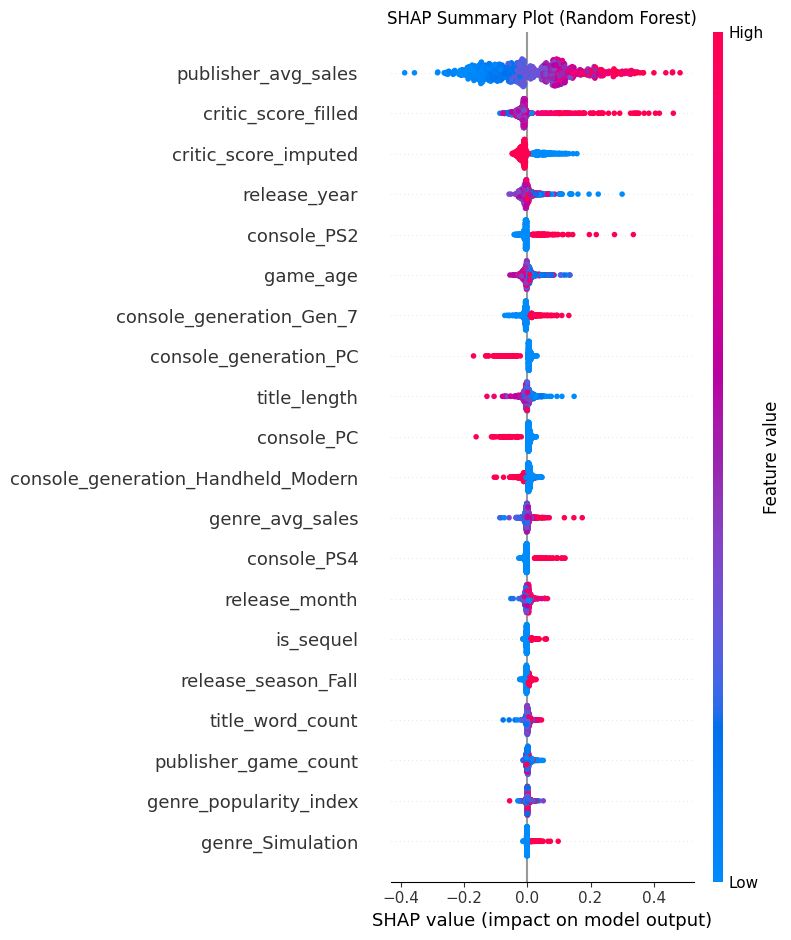

SHAP completed on 1000 sampled rows.


In [1]:
# SHAP explainability setup
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

try:
    import shap
except ImportError as e:
    raise ImportError("shap is not installed. Run: %pip install shap") from e

base_dir = Path.cwd()
model_path = base_dir / "models" / "trained_models" / "best_rf_model.pkl"
config_path = base_dir / "feature_config.json"
data_path = base_dir / "video_games_processed.csv"

if not model_path.exists() or not config_path.exists() or not data_path.exists():
    raise FileNotFoundError(
        "Required files not found. Ensure main.ipynb is run from cp-final/cp-final and model artifacts exist."
    )

with open(config_path, "r", encoding="utf-8") as f:
    feature_config = json.load(f)

all_features = feature_config["all_features"]

df_infer = pd.read_csv(data_path)
pipeline = joblib.load(model_path)

X_all = df_infer[all_features].copy()

# Use a capped sample to keep SHAP runtime practical.
sample_n = min(1000, len(X_all))
X_sample = X_all.sample(n=sample_n, random_state=42)

preprocessor = pipeline.named_steps["preprocessor"]
regressor = pipeline.named_steps["regressor"]

X_sample_transformed = preprocessor.transform(X_sample)

num_features = feature_config["numerical_features"]
bin_features = feature_config["binary_features"]
cat_features = feature_config["categorical_features"]
cat_feature_names = (
    preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(cat_features)
    .tolist()
)
feature_names_transformed = num_features + cat_feature_names + bin_features

explainer = shap.TreeExplainer(regressor)
shap_values = explainer.shap_values(X_sample_transformed)

plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values,
    X_sample_transformed,
    feature_names=feature_names_transformed,
    show=False
)
plt.title("SHAP Summary Plot (Random Forest)")
plt.tight_layout()
plt.show()

print(f"SHAP completed on {sample_n} sampled rows.")

In [2]:
# Inference testing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Batch inference on a holdout sample for quick validation.
holdout_n = min(2000, len(df_infer))
holdout_df = df_infer.sample(n=holdout_n, random_state=7)
X_holdout = holdout_df[all_features].copy()

y_pred_log = pipeline.predict(X_holdout)
y_pred = np.expm1(y_pred_log)

if "log_total_sales" in holdout_df.columns:
    y_true = np.expm1(holdout_df["log_total_sales"].values)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))

    non_zero_mask = y_true > 0
    mape = float(np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100)

    print("Inference metrics on sampled holdout:")
    print(f"  RMSE: {rmse:.4f} million")
    print(f"  MAE:  {mae:.4f} million")
    print(f"  MAPE: {mape:.2f}%")

# Inference sanity checks
assert np.isfinite(y_pred).all(), "Inference produced non-finite values."
assert (y_pred >= 0).all(), "Inference produced negative sales predictions."

print(f"Inference test passed on {holdout_n} rows.")

# Single-record inference example
single_x = X_holdout.iloc[[0]].copy()
single_pred = float(np.expm1(pipeline.predict(single_x))[0])

print("\nSingle game inference example:")
print(single_x.iloc[0].to_dict())
print(f"Predicted total_sales(mil): {single_pred:.4f}")

Inference metrics on sampled holdout:
  RMSE: 0.3350 million
  MAE:  0.1245 million
  MAPE: 94.98%
Inference test passed on 2000 rows.

Single game inference example:
{'console': 'PSP', 'genre': 'Role-Playing', 'publisher': 'Xseed Games', 'console_generation': 'Handheld_Modern', 'release_season': 'Fall', 'publisher_tier': 'Small', 'release_year': 2010, 'release_month': 11, 'release_quarter': 4, 'game_age': 14, 'critic_score_filled': 8.2, 'title_length': 24.0, 'title_word_count': 5.0, 'publisher_game_count': 79, 'publisher_avg_sales': 0.1644303797468354, 'genre_avg_sales': 0.2871746459878624, 'genre_popularity_index': 35.88563917186987, 'is_holiday_release': 1, 'is_sequel': 0, 'is_special_edition': 0, 'has_online_indicator': 0, 'critic_score_imputed': 0}
Predicted total_sales(mil): 0.2707
